# Gradient image features: Histogram of Oriented Gradients (HoG) introduction

**Overview**
This exercise introduces image gradient extraction and demonstrates how to compute Histogram of Oriented Gradients (HoG) features on a sample image. The extracted HoG features will be used in later exercises for classification.


<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#descriptor">Task 1: Calculate the HoG descriptor</a>
            </li>
            <li>
            <a href="#test1">Task 2: Reflect</a>
            </li>
            <li>
            <a href="#test">Task 3: Visualizing and understanding the HoG de…</a>
            </li>
            <li>
            <a href="#test2">Task 4: Reflect</a>
            </li>
            <li>
            <a href="#compare_images">Task 5: Comparing HoG Features</a>
            </li>
            <li>
            <a href="#compare_images1">Task 6: Evaluating HoG Features</a>
            </li>
            <li>
            <a href="#interpretation">Task 7: Interpretation/ Understanding questions</a>
            </li>
            <li>
            <a href="#interpretation1">Task 8: Interpretation/ Understanding questions</a>
            </li>
        </ul>
    </div>
</article>

The cell below loads a sample image.


(480, 852, 3)


Text(0.5, 1.0, 'Input image')

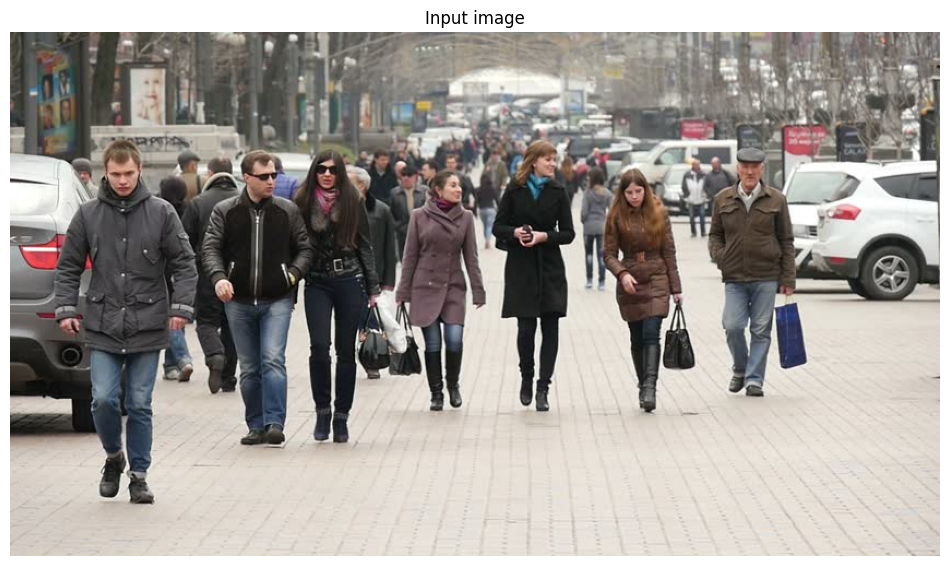

In [1]:
## load input image
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import hog
from skimage import data, exposure


fn =  "./data/people01.jpg"
image = plt.imread(fn)
print(image.shape)

fig, ax1 = plt.subplots(figsize=(12, 8), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

The following section: 
- Introduces the [HoG descriptor](https://en.wikipedia.org/wiki/Histogram_of_oriented_gradients)

- Shows how to calculate a HoG featues for an image including a visualization of the HoG descriptor.

## Overview of Histogram of Oriented Gradients (HoG) Algorithm
The Histogram of Oriented Gradients (HoG) is a feature descriptor used to detect objects in images. 
The function [skimage.feature.HoG](https://scikit-image.org/docs/stable/api/skimage.feature.html<elem-3>.feature.HoG)
 computes
the HoG features. It also returns the feature descriptor vector (`fd`
), in which its
size is equal to the number of: Bins $\times$ Block Columns
$\times$ Block Rows $\times$ Cells in the Block.
The process involves the following stages:
**1. Preprocessing / Smoothing:**


Initially, the image undergoes a global intensity normalization to diminish the effects of lighting. A common technique involves gamma (power-law) transformation of pixels, which can be achieved by calculating the square root or logarithm of each color channel. This stage helps in reducing the impact of local shadowing and highlights variations since the image texture strength is generally related to the local surface illumination.
**2. Calculation of Image Gradients:**


This stage focuses on computing image gradients. The standard procedure is to either convert the image to grayscale or use the most prominent color channel. 
**Info**
This step was implemented by us in the first part of the exercise.

 
**3. Creation of Cells and Calculation of normalized Histograms:**


The objective is to create an encoding of local gradients. This involves partitioning the image window into smaller spatial cells. Each cell creates a histogram of image gradient orientations and performs various steps to normalize intensities and histograms. 
**4. Compilation of Feature Vector:**


The HoG feature is constructed by concatenating the histograms for each cell into a combined vector. 

---
**Task 1 (easy): Calculate the HoG descriptor👩‍💻**
1. Run the cell below to calculate and plot the HoG descriptor. 


---

(270, 220, 3)


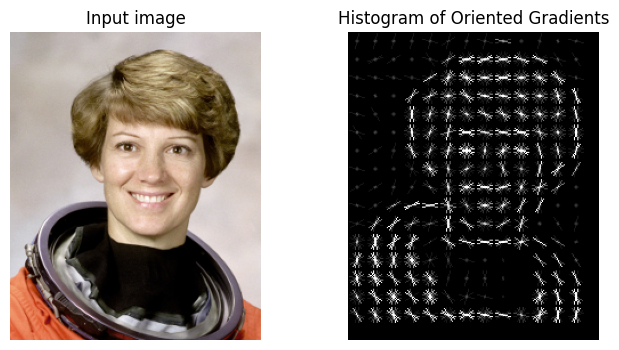

In [2]:
# load new image
image1 = data.astronaut()[:270,100:320]
print(image1.shape)

feature_vector=True,
bins = 8 
pixels_per_cell = 16
cells_per_block = 4 

(fd1, HoG_feat1) = hog(
    image1,
    orientations=bins,
    pixels_per_cell=(pixels_per_cell, pixels_per_cell),
    cells_per_block=(cells_per_block, cells_per_block),
    block_norm="L2",
    visualize=True,
    feature_vector=True,
    channel_axis=-1
)
HoG_feat1 = HoG_feat1.astype("uint8")


# after implementation of the HoG function, run the following plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image1, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
HoG_image_rescaled = exposure.rescale_intensity(HoG_feat1, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(HoG_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()


---
**Task 2 (easy): Reflect💡**
1. What charaterizes the local histograms and the HoG feature combined?


---

In [ ]:
#Write your reflections here..
# The HoG features follow the lines, i.e. borders of objects.


---
**Task 3 (easy): Visualizing and understanding the HoG descriptor👩‍💻**
Change the parameters of the HoG descriptor and visualize how the feature descriptor changes.
1. Change the parameters for the HoG descriptor:

- the number of bins
- the number of pixels per cell
- the number of cells per block

and visually observe how the dimensionality and the features change.
2. The following cell loads an image of a cat. Calculate the HoG descriptor of the cat image.


---

(270, 220, 3)


Text(0.5, 1.0, 'Histogram of Oriented Gradients')

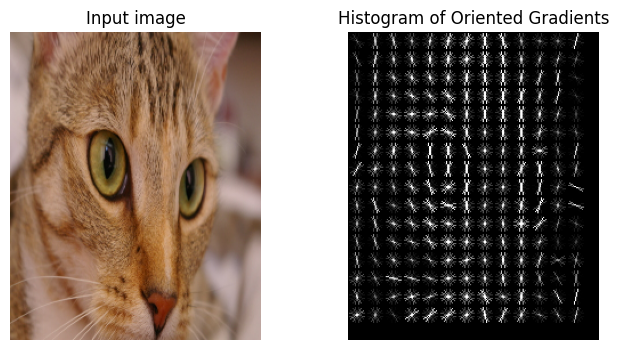

In [17]:
image2 = data.cat()[:270,:440:2]
print(image2.shape)

feature_vector=True,
bins = 8 # how granular are the gradients? -> more granular = less random spreading, softer distributions , less granualar = few gradients, sometimes too generalised
pixels_per_cell = 16 # How big is the square we calculate the gradient within?
cells_per_block = 4 # ???

(fd2, HoG_feat2) = hog(
    image2,
    orientations=bins,
    pixels_per_cell=(pixels_per_cell, pixels_per_cell),
    cells_per_block=(cells_per_block, cells_per_block),
    block_norm="L2",
    visualize=True,
    feature_vector=True,
    channel_axis=-1
)

# after implementation of the HoG function, run the following plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image2, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
HoG_image_rescaled2 = exposure.rescale_intensity(HoG_feat2, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(HoG_image_rescaled2, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')


---
**Task 4 (easy): Reflect💡**
1. What charaterizes the local histograms and the HoG feature combined?


---

**What characterizes the local histograms and the HoG feature combined:**

1. **Local spatial information**: Each local histogram captures the distribution of gradient orientations within a small cell, encoding local edge/contour patterns.

2. **Orientation distribution**: Each histogram shows dominant edge directions in that region, representing local shape and texture information.

3. **Block normalization**: Histograms are normalized within blocks (e.g., L2 normalization), making the descriptor more robust to lighting and contrast variations.

4. **Spatial relationships**: By concatenating histograms from all cells, the combined feature preserves spatial layout, capturing both local patterns and their relative positions.

5. **Invariance properties**: The combination provides some invariance to:
   - Local lighting changes (through normalization)
   - Small geometric variations (through local histograms)
   - While maintaining spatial structure (through concatenation)

6. **Dimensionality**: The final feature vector size is: `bins × number_of_blocks × cells_per_block`, creating a fixed-length descriptor suitable for machine learning.

In summary, local histograms capture orientation patterns in small regions, and combining them with block normalization creates a robust, spatially-aware descriptor that is effective for object detection and classification.


---
**Task 5 (easy): Comparing HoG Features👩‍💻**
This task is about comparing HoG features of two different images. 
1. Change the parameters of the HoG descriptor and visually compare the HoG features.
2. Calculate the normalized (use `np.linalg.norm`
 to normalize vectors) scalar product between the two feature vectors `fd1`
 and `fd2`
.     - What is the scalar product between two feature vectors? (compare it to the value of 1 )
    - Repeat the calculation for multiple HoG filter parameters, and describe how these parameters influence the result. 




**Hint**
Set `feature_vector`
=True in `HoG`


3. Based on the cosine similarity (normalized inner product), explain how HoG features can be used to classify different images of cat/humans.


---

In [23]:
# Ensure fd1 and fd2 are calculated (from Task 1 and Task 3)
# If fd2 is not calculated yet, calculate it first:
# fd2, HoG_image2 = hog(image2, orientations=8, pixels_per_cell=(16, 16), 
#                       cells_per_block=(4, 4), block_norm="L2", 
#                       visualize=True, feature_vector=True)

# Normalize the feature vectors
fd1_normalized = fd1 / np.linalg.norm(fd1)
fd2_normalized = fd2 / np.linalg.norm(fd2)

# Calculate the normalized scalar product (cosine similarity)
cosine_similarity = np.dot(fd1_normalized, fd2_normalized)

print(f"Normalized scalar product (cosine similarity): {cosine_similarity:.4f}")
print(f"Comparison to 1: {cosine_similarity:.4f} (closer to 1 means more similar)")

# Test with different HoG parameters
print("\n--- Testing different HoG parameters ---\n")

param_configs = [
    {"bins": 8, "pixels_per_cell": 16, "cells_per_block": 4},
    {"bins": 9, "pixels_per_cell": 16, "cells_per_block": 4},
    {"bins": 8, "pixels_per_cell": 8, "cells_per_block": 4},
    {"bins": 8, "pixels_per_cell": 16, "cells_per_block": 2},
]

for i, params in enumerate(param_configs, 1):
    # Calculate HoG for both images with these parameters
    fd1_test = hog(image1, orientations=params["bins"],
                      pixels_per_cell=(params["pixels_per_cell"], params["pixels_per_cell"]),
                      cells_per_block=(params["cells_per_block"], params["cells_per_block"]),
                      block_norm="L2", visualize=False, feature_vector=True,
                      channel_axis=-1 if len(image1.shape) == 3 else None)
    
    fd2_test = hog(image2, orientations=params["bins"],
                      pixels_per_cell=(params["pixels_per_cell"], params["pixels_per_cell"]),
                      cells_per_block=(params["cells_per_block"], params["cells_per_block"]),
                      block_norm="L2", visualize=False, feature_vector=True,
                      channel_axis=-1 if len(image1.shape) == 3 else None)
    
    # Normalize and calculate similarity
    fd1_norm = fd1_test / np.linalg.norm(fd1_test)
    fd2_norm = fd2_test / np.linalg.norm(fd2_test)
    similarity = np.dot(fd1_norm, fd2_norm)
    
    print(f"Config {i} (bins={params['bins']}, pixels_per_cell={params['pixels_per_cell']}, "
          f"cells_per_block={params['cells_per_block']}): {similarity:.4f}")

Normalized scalar product (cosine similarity): 0.4301
Comparison to 1: 0.4301 (closer to 1 means more similar)

--- Testing different HoG parameters ---

Config 1 (bins=8, pixels_per_cell=16, cells_per_block=4): 0.4301
Config 2 (bins=9, pixels_per_cell=16, cells_per_block=4): 0.4209
Config 3 (bins=8, pixels_per_cell=8, cells_per_block=4): 0.3720
Config 4 (bins=8, pixels_per_cell=16, cells_per_block=2): 0.5263


**How HoG features can be used to classify different images of cats/humans based on cosine similarity:**

1. **Feature extraction**: HoG features extract orientation patterns that are characteristic of different object classes. Cats and humans have distinct edge patterns, shapes, and structures that are captured in their HoG descriptors.

2. **Similarity measurement**: Cosine similarity (normalized inner product) measures how similar two HoG feature vectors are:
   - **High similarity (close to 1)**: Images with similar HoG features, likely from the same class (e.g., two cat images or two human images)
   - **Low similarity (close to 0 or negative)**: Images with different HoG features, likely from different classes (e.g., a cat image vs. a human image)

3. **Classification approach**:
   - **Template matching**: Compare a test image's HoG features against reference templates of cats and humans. The class with the highest cosine similarity is the predicted class.
   - **k-Nearest Neighbors (k-NN)**: Find k training images with highest cosine similarity to the test image, and classify based on majority vote of their labels.
   - **Support Vector Machines (SVM)**: Use HoG features as input to train an SVM classifier that learns decision boundaries between cat and human features.

4. **Why it works**: 
   - HoG captures local edge orientations and spatial relationships that are consistent within a class (e.g., humans have vertical edges for body/torso, horizontal for limbs; cats have different proportions and edge patterns)
   - Cosine similarity is robust to variations in lighting and contrast (due to normalization), making it suitable for comparing HoG features
   - The spatial structure preserved in HoG features helps distinguish between objects with different shapes and layouts

5. **Practical workflow**:
   - Extract HoG features from labeled training images (cats and humans)
   - For a new test image, extract its HoG features
   - Calculate cosine similarity with all training examples or use a trained classifier
   - Classify based on highest similarity or classifier output


---
**Task 6 (easy): Evaluating HoG Features💡**
This task will compare two HoG features of different images. 
1. What is the scalar product between two feature vectors? (compare it to the value of 1 )
2. Repeat the calculation for multiple HoG filter settings, notice a difference? 


**Hint**
Set `feature_vector`
=True in `HoG`


3. Based on the cosine similarity (normalized inner product), explain how HoG features can be used to classify different images of cat/humans.


---

In [26]:
# Calculate normalized scalar product (cosine similarity) between fd1 and fd2
# Normalize the feature vectors
fd1_normalized = fd1 / np.linalg.norm(fd1)
fd2_normalized = fd2 / np.linalg.norm(fd2)

# Calculate the normalized scalar product (cosine similarity)
scalar_product = np.dot(fd1_normalized, fd2_normalized)

print(f"Normalized scalar product: {scalar_product:.4f}")
print(f"Comparison to 1: {scalar_product:.4f} (value ranges from -1 to 1)")
print(f"Distance from 1: {abs(1 - scalar_product):.4f}")

# Test with multiple HoG filter settings
print("\n" + "="*60)
print("Testing different HoG filter settings:")
print("="*60 + "\n")

# Different parameter configurations
configs = [
    {"bins": 8, "pixels_per_cell": 16, "cells_per_block": 4, "name": "Default"},
    {"bins": 9, "pixels_per_cell": 16, "cells_per_block": 4, "name": "More bins"},
    {"bins": 8, "pixels_per_cell": 8, "cells_per_block": 4, "name": "Smaller cells"},
    {"bins": 8, "pixels_per_cell": 16, "cells_per_block": 2, "name": "Smaller blocks"},
    {"bins": 4, "pixels_per_cell": 32, "cells_per_block": 2, "name": "Coarse"},
    {"bins": 16, "pixels_per_cell": 8, "cells_per_block": 4, "name": "Fine"},
]

results = []

for config in configs:
    # Calculate HoG for image1
    fd1_test = hog(image1, 
                      orientations=config["bins"],
                      pixels_per_cell=(config["pixels_per_cell"], config["pixels_per_cell"]),
                      cells_per_block=(config["cells_per_block"], config["cells_per_block"]),
                      block_norm="L2", 
                      visualize=False, 
                      feature_vector=True,
                      channel_axis=-1 if len(image1.shape) == 3 else None)
    
    # Calculate HoG for image2
    fd2_test = hog(image2, 
                      orientations=config["bins"],
                      pixels_per_cell=(config["pixels_per_cell"], config["pixels_per_cell"]),
                      cells_per_block=(config["cells_per_block"], config["cells_per_block"]),
                      block_norm="L2", 
                      visualize=False, 
                      feature_vector=True,
                      channel_axis=-1 if len(image1.shape) == 3 else None)
    
    # Normalize and calculate similarity
    fd1_norm = fd1_test / np.linalg.norm(fd1_test)
    fd2_norm = fd2_test / np.linalg.norm(fd2_test)
    similarity = np.dot(fd1_norm, fd2_norm)
    
    results.append({
        "config": config["name"],
        "similarity": similarity,
        "bins": config["bins"],
        "pixels_per_cell": config["pixels_per_cell"],
        "cells_per_block": config["cells_per_block"]
    })
    
    print(f"{config['name']:20s} | bins={config['bins']:2d}, "
          f"pixels/cell={config['pixels_per_cell']:2d}, "
          f"cells/block={config['cells_per_block']:2d} | "
          f"Similarity: {similarity:.4f}")

print("\n" + "="*60)
print("Observations:")
print("="*60)
print(f"Highest similarity: {max(results, key=lambda x: x['similarity'])['config']} "
      f"({max(results, key=lambda x: x['similarity'])['similarity']:.4f})")
print(f"Lowest similarity: {min(results, key=lambda x: x['similarity'])['config']} "
      f"({min(results, key=lambda x: x['similarity'])['similarity']:.4f})")
print(f"Range: {max(r['similarity'] for r in results) - min(r['similarity'] for r in results):.4f}")

Normalized scalar product: 0.4301
Comparison to 1: 0.4301 (value ranges from -1 to 1)
Distance from 1: 0.5699

Testing different HoG filter settings:

Default              | bins= 8, pixels/cell=16, cells/block= 4 | Similarity: 0.4301
More bins            | bins= 9, pixels/cell=16, cells/block= 4 | Similarity: 0.4209
Smaller cells        | bins= 8, pixels/cell= 8, cells/block= 4 | Similarity: 0.3720
Smaller blocks       | bins= 8, pixels/cell=16, cells/block= 2 | Similarity: 0.5263
Coarse               | bins= 4, pixels/cell=32, cells/block= 2 | Similarity: 0.6499
Fine                 | bins=16, pixels/cell= 8, cells/block= 4 | Similarity: 0.3171

Observations:
Highest similarity: Coarse (0.6499)
Lowest similarity: Fine (0.3171)
Range: 0.3327



---
**Task 7 (medium): Interpretation/ Understanding questions👩‍💻**
Select several images from the dataset (`peopleXY.jpg`
) and visually compare the HoG features of people and non-people images. 
1. Run the cell below to visualizes the HoG features


---

(480, 852, 3)
 HoG feature vector shape: (27, 50, 4, 4, 8)
 HoG feature vector shape after vectorization: (172800,)


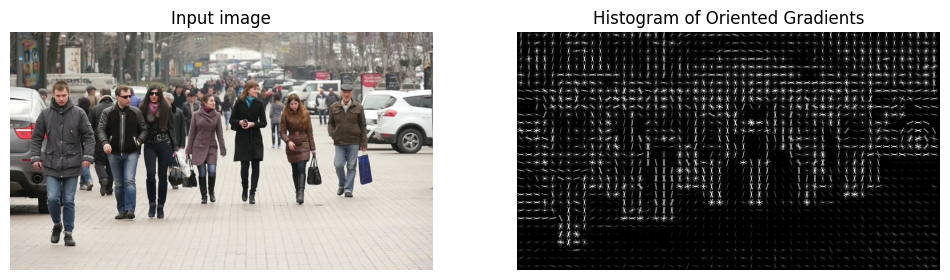

In [31]:
# load new image
fn =  "./data/people01.jpg"
image = plt.imread(fn)
print(image.shape)

feature_vector=True,
bins = 8 
pixels_per_cell = 16
cells_per_block = 4 

# Compute HoG.
(fd, HoG_feat) = hog(
    image,
    orientations=bins,
    pixels_per_cell=(pixels_per_cell, pixels_per_cell),
    cells_per_block=(cells_per_block, cells_per_block),
    block_norm="L2",
    visualize=True,
    feature_vector=False,
    channel_axis=-1
)
HoG_feat = HoG_feat.astype("uint8")


print(f' HoG feature vector shape: {fd.shape}')
print(f' HoG feature vector shape after vectorization: {fd.reshape(-1).shape}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
HoG_image_rescaled = exposure.rescale_intensity(HoG_feat, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(HoG_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')

plt.show()


---
**Task 8 (medium): Interpretation/ Understanding questions💡**
1. How could HoG features be used to classify different objects in a larger image with multiple people? 

2. Explain how the HoG features use local information to create an understanding of the content of the full image? 



---

In [0]:
# write your reflections here
# 1: one can classify subsections of the image. Just like we did with
# # the sunflowers in week 10 i believe.
# 2: Since the local HoGs only describe the local state, they do not know
# # much about what the image comprises in total. Combining HoGs gives us
# # an understanding of a larger subsection of the image!